In [19]:
# !pip install --upgrade pip
!pip install -q matplotlib==v3.8.0
!pip install -q torch-tb-profiler
!pip install -q deepspeed
!pip install -q pyquaternion==0.9.9
!pip install -q opencv-python==4.8.0.74
!pip install -q pytorch-lightning #== 2.4.0 ---------------------> MAY BE OF NO USE
!pip install -q lightning #==2.4.0
!pip install -q fvcore==0.1.5.post20221221
!pip install -q efficientnet_pytorch==0.7.1
!pip install -q timm==1.0.8
!pip install -q scikit_image==0.24.0
!pip install -q torchmetrics==1.7.1
!pip install -q nuscenes-devkit==v1.1.11
!pip install -q torchmetrics==1.7.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 73.1 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.3 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.3 MB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 28.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.1/821.1 kB 13.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [20]:
import os
import sys
!pip install -q gdown
import gdown

In [21]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
os.makedirs('/kaggle/working/Maps', exist_ok=True)

/kaggle/input/nuscenes-trainval-metadata/v1.0-trainval_meta.tgz
/kaggle/input/nuscenes-blob1/v1.0-trainval01_blobs_camera.tgz
/kaggle/input/nuscenes-blob1/v1.0-trainval01_keyframes.tgz


# Secrets

In [22]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

In [23]:
!ls /kaggle/input

nuscenes-blob1	nuscenes-trainval-metadata


# Clone Repository

In [24]:
sys.path.append('/kaggle/working/grad_proj')
sys.path.append('/kaggle/working/nuscenes-devkit/python-sdk')

Tokens


In [2]:
from kaggle_secrets import UserSecretsClient
secret_label = "github_token"
github_token = UserSecretsClient().get_secret(secret_label)

In [3]:
!rm -r  /kaggle/working/grad_proj

repo_url = 'https://github.com/marmoh2002/ST-P3-DeepSpeed-Kaggle'
branch =  'main'
clone_command = f'git clone -b {branch} --single-branch https://{github_token}@github.com/marmoh2002/grad_proj.git'
!{clone_command}
sys.path.append('/kaggle/working/grad_proj')

Cloning into 'grad_proj'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 203 (delta 49), reused 35 (delta 35), pack-reused 136 (from 1)
Receiving objects: 100% (203/203), 2.15 MiB | 14.46 MiB/s, done.
Resolving deltas: 100% (74/74), done.


NameError: name 'sys' is not defined

In [ ]:
!rm -r  /kaggle/working/nuscenes-devkit

#______________________________________________________________#
repo_url = 'https://github.com/marmoh2002/nuscenes-devkit.git'
branch = 'first-try'
clone_command = f'git clone -b {branch} --single-branch https://{github_token}@github.com/marmoh2002//nuscenes-devkit.git'
!{clone_command}


# Nuscenes download

In [27]:
# !rm -r /data/Nuscenes
# !rm -r /kaggle/working/tensorboard_logs

In [28]:
extract_folder = "/data/Nuscenes"
os.makedirs(extract_folder, exist_ok=True)

In [29]:
os.makedirs('/kaggle/working/Maps', exist_ok=True)
URL = 'https://drive.google.com/uc?id=1pJJErp8BMZRVUYJxd-K0JWw4J6u1JnFj'
output = 'Maps/nuScenes-map-expansion-v1.3.zip'
gdown.download(URL, output, quiet = False)
URL = 'https://drive.google.com/uc?id=1sUCztCRHnpLwzYjQ-Qcub34wjE1UCWMd'
output = 'Maps/can_bus.zip'
gdown.download(URL, output, quiet = False)

Downloading...
From (original): https://drive.google.com/uc?id=1pJJErp8BMZRVUYJxd-K0JWw4J6u1JnFj
From (redirected): https://drive.google.com/uc?id=1pJJErp8BMZRVUYJxd-K0JWw4J6u1JnFj&confirm=t&uuid=c2dfeb15-652e-4b95-8bfe-80c31794a537
To: /kaggle/working/Maps/nuScenes-map-expansion-v1.3.zip
100%|██████████| 399M/399M [00:01<00:00, 241MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1sUCztCRHnpLwzYjQ-Qcub34wjE1UCWMd
From (redirected): https://drive.google.com/uc?id=1sUCztCRHnpLwzYjQ-Qcub34wjE1UCWMd&confirm=t&uuid=01244aad-bb64-4318-9480-8016204b8847
To: /kaggle/working/Maps/can_bus.zip
100%|██████████| 781M/781M [00:06<00:00, 128MB/s]  


'Maps/can_bus.zip'

In [30]:
!unzip -q -o /kaggle/working/Maps/nuScenes-map-expansion-v1.3.zip -d /data/Nuscenes/maps/
!unzip -q -o /kaggle/working/Maps/can_bus.zip -d /data/Nuscenes
!rm -r /kaggle/working/Maps/ 

In [31]:
def exclude_blobs(excluded):
    extracted = []
    for blob in excluded:
        if blob <= 9:
            extracted.append(f"v1.0-trainval0{blob}_keyframes.tgz")
            extracted.append(f"v1.0-trainval0{blob}_blobs_camera.tgz")
        elif blob > 9:
            extracted.append(f"v1.0-trainval{blob}_keyframes.tgz")
            extracted.append(f"v1.0-trainval{blob}_blobs_camera.tgz")
    return extracted

# Entering Scenes to Be Exculded


In [32]:
extracted = exclude_blobs([2,3,4,5,6,7,8,9,10])
extracted

['v1.0-trainval02_keyframes.tgz',
 'v1.0-trainval02_blobs_camera.tgz',
 'v1.0-trainval03_keyframes.tgz',
 'v1.0-trainval03_blobs_camera.tgz',
 'v1.0-trainval04_keyframes.tgz',
 'v1.0-trainval04_blobs_camera.tgz',
 'v1.0-trainval05_keyframes.tgz',
 'v1.0-trainval05_blobs_camera.tgz',
 'v1.0-trainval06_keyframes.tgz',
 'v1.0-trainval06_blobs_camera.tgz',
 'v1.0-trainval07_keyframes.tgz',
 'v1.0-trainval07_blobs_camera.tgz',
 'v1.0-trainval08_keyframes.tgz',
 'v1.0-trainval08_blobs_camera.tgz',
 'v1.0-trainval09_keyframes.tgz',
 'v1.0-trainval09_blobs_camera.tgz',
 'v1.0-trainval10_keyframes.tgz',
 'v1.0-trainval10_blobs_camera.tgz']

In [33]:
import tarfile

def extract_tgz_to_folder(tgz_file_path, extract_to):
    print(f"Extracting {tgz_file_path} to {extract_to}")
    os.makedirs(extract_to, exist_ok=True)
    with tarfile.open(tgz_file_path, 'r:gz') as tar:
        tar.extractall(path=extract_to)

def extract_tar_to_folder(tar_file_path, extract_to):
    print(f"Extracting {tar_file_path} to {extract_to}")
    os.makedirs(extract_to, exist_ok=True)
    with tarfile.open(tar_file_path, 'r') as tar:
        tar.extractall(path=extract_to)

path = "/kaggle/input"
extract_folder = "/data/Nuscenes"
 #["v1.0-trainval04_keyframes.tgz" ,"v1.0-trainval04_blobs_camera.tgz", ""]
for folder_name in os.listdir(path):
    print("Folder: ", folder_name)
    for output_name in os.listdir(os.path.join(path,folder_name)):
        print(output_name)
        # save_file = download_file(download_url, save_file, md5)
        # download_data[output_name] = [download_url, save_file, md5]
        # print("Extracting file...")
        # print(type(path), type(output_name))
        save_file = os.path.join(path,folder_name, output_name)
        # print(save_file)
        
        if output_name in extracted:
            print("already extracted")
        elif output_name.endswith(".tar") and output_name not in extracted:
            extract_tar_to_folder(save_file, extract_folder)
            extracted.append(output_name)
        elif output_name.endswith(".tgz") and output_name not in extracted:
            extract_tgz_to_folder(save_file, extract_folder)
            extracted.append(output_name)
        else:
            print("Unknown file type", output_name)
        if os.path.exists(output_name):
            os.remove(output_name)
            print(f"{output_name} deleted successfully.")
print("Done!")

Folder:  nuscenes-trainval-metadata
v1.0-trainval_meta.tgz
Extracting /kaggle/input/nuscenes-trainval-metadata/v1.0-trainval_meta.tgz to /data/Nuscenes
Folder:  nuscenes-blob1
v1.0-trainval01_blobs_camera.tgz
Extracting /kaggle/input/nuscenes-blob1/v1.0-trainval01_blobs_camera.tgz to /data/Nuscenes
v1.0-trainval01_keyframes.tgz
Extracting /kaggle/input/nuscenes-blob1/v1.0-trainval01_keyframes.tgz to /data/Nuscenes
Done!


In [34]:
!ls /data/Nuscenes

can_bus  LICENSE  maps	samples  sweeps  v1.0-trainval


In [35]:
!pwd

/kaggle/working


In [36]:
!du -lah /data/Nuscenes/v1.0-trainval

4.0K	/data/Nuscenes/v1.0-trainval/visibility.json
8.0K	/data/Nuscenes/v1.0-trainval/category.json
4.0K	/data/Nuscenes/v1.0-trainval/attribute.json
616M	/data/Nuscenes/v1.0-trainval/ego_pose.json
12K	/data/Nuscenes/v1.0-trainval/log.json
4.0K	/data/Nuscenes/v1.0-trainval/sensor.json
16M	/data/Nuscenes/v1.0-trainval/instance.json
3.2M	/data/Nuscenes/v1.0-trainval/calibrated_sensor.json
4.0K	/data/Nuscenes/v1.0-trainval/map.json
7.1M	/data/Nuscenes/v1.0-trainval/sample.json
280K	/data/Nuscenes/v1.0-trainval/scene.json
1.3G	/data/Nuscenes/v1.0-trainval/sample_data.json
557M	/data/Nuscenes/v1.0-trainval/sample_annotation.json
2.5G	/data/Nuscenes/v1.0-trainval


In [37]:
# !mkdir -p /data/Nuscenes  # Make the directory to store the nuScenes dataset in.
# !wget https://www.nuscenes.org/data/v1.0-mini.tgz  # Download the nuScenes mini split.

# !tar -xf /kaggle/working/v1.0-mini.tgz -C /data/Nuscenes  # Uncompress the nuScenes mini split.
# !rm -r /kaggle/working/v1.0-mini.tgz

# extract_scenes.py

## scr

In [38]:
!python /kaggle/working/grad_proj/extract_scenes.py /data/Nuscenes/samples/CAM_FRONT /data/Nuscenes/v1.0-trainval --output_file1 my_scene_names.txt --output_file2 my_log_names.txt

Scanning data folder: /data/Nuscenes/samples/CAM_FRONT

Found 11 unique potential logfile names from filenames:
  - n008-2018-08-01-15-16-36-0400
  - n008-2018-08-01-15-52-19-0400
  - n015-2018-07-18-11-07-57+0800
  - n015-2018-07-18-11-18-34+0800
  - n015-2018-07-18-11-41-49+0800
  - n015-2018-07-18-11-50-34+0800
  - n015-2018-07-24-10-42-41+0800
  - n015-2018-07-24-11-03-52+0800
  - n015-2018-07-24-11-13-19+0800
  - n015-2018-07-24-11-22-45+0800
  - n015-2018-08-02-17-16-37+0800

Loading log metadata: /data/Nuscenes/v1.0-trainval/log.json
Loaded 68 log records.

Loading scene metadata: /data/Nuscenes/v1.0-trainval/scene.json
Loaded 850 scene records.

Mapping 11 present logfiles to log tokens...
Found, 11 matching log records in log.json.

Searching 850 scenes for matching log tokens...
--------------------
Log token usage counts (scenes per token):
  Log Token 6b6513e6c8384cec88775cae30b78c0e (n015-2018-07-18-11-07-57+0800): 2 scenes
  Log Token 92af2609d31445e5a71b2d895376fed6 (n01

# Filtering

## Filter command

In [39]:
!rm -r /kaggle/working/v1.0-trainval-filtered
!mkdir -p /kaggle/working/v1.0-trainval-filtered

# input_dir output_dir scene_file logs_file
!python /kaggle/working/grad_proj/filter_nuscenes_metadata.py /data/Nuscenes/v1.0-trainval /kaggle/working/v1.0-trainval-filtered /kaggle/working/my_scene_names.txt /kaggle/working/my_log_names.txt

# # !rm -r /data/Nuscenes/v1.0-trainval

# # !cp -r /kaggle/working/v1.0-trainval-filtered /data/Nuscenes/v1.0-trainval

 Starting NuScenes Metadata Filtering Process 
Input Metadata Directory : /data/Nuscenes/v1.0-trainval
Output Filtered Directory: /kaggle/working/v1.0-trainval-filtered
Target Scene List File   : /kaggle/working/my_scene_names.txt
Target Logs List File   : /kaggle/working/my_log_names.txt
Reading target scene names from: /kaggle/working/my_scene_names.txt
Found 96 unique target scene names.
Reading target scene names from: /kaggle/working/my_log_names.txt
Found 11 unique target scene names.

--- Processing Table: log ---
  Loading log.json...
  Loaded 68 records from log.json in 0.00s.
  Processed 68 records, kept 11 records for log.
  Time for log: 0.00s

--- Processing Table: map ---
  Loading map.json...
  Loaded 4 records from map.json in 0.00s.
  Keeping all records for small table: map
  Processed 0 records, kept 4 records for map.
  Time for map: 0.00s

--- Processing Table: scene ---
  Loading scene.json...
  Loaded 850 records from scene.json in 0.00s.
  Processed 850 records,

# get_entries_by_token_and_format

In [40]:
import json
import pprint
import os


folder_name="CAM_FRONT"
trainval_path="/data/Nuscenes/v1.0-trainval"
filtered_trainval_path = "/kaggle/working/v1.0-trainval-filtered"

def get_prefixed_file_list(folder_path: str, base_prefix: str) -> list[str]:
    """
    Lists files in a folder, extracts a sub-prefix from each filename,
    and prepends the base_prefix and the extracted sub-prefix to the filename.

    Args:
        folder_path (str): The path to the folder containing the files.
        base_prefix (str): The prefix to prepend to the filename.

    Returns:
        list[str]: A list of strings, where each string is the newly constructed path.
    """

    output_filenames = []

    # List all files in the folder
    for filename in os.listdir(folder_path):
        # Check if it's a file (not a subfolder)
        if os.path.isfile(os.path.join(folder_path, filename)):
            # Split the filename by underscore
            parts = os.path.splitext(filename)[0].split('__')

            # Extract the sub-prefix (parts between the first and the last)
            if len(parts) > 2:
                sub_prefix = '_'.join(parts[1:-1])

                # Prepend the base_prefix and sub_prefix to the filename
                new_filename = os.path.join(base_prefix, sub_prefix, filename)

                # Normalize the path (handle cases where base_prefix doesn't end with '/')
                new_filename = os.path.normpath(new_filename)

                output_filenames.append(new_filename)

    return output_filenames

# Example Usage:


def get_entries_by_token_and_format(json_path, token_value, key, fileformat_value=None, filename_prefix=None):
    """
    Get all entries from a JSON file where the specified key equals a specific value,
    optionally where 'fileformat' equals a specific value, and/or
    optionally where 'filename' starts with a specified prefix
    
    Args:
        json_path (str): Path to the JSON file
        token_value (str): The value to match against the specified key
        key (str): The key to check for token_value
        fileformat_value (str, optional): If provided, also filter by this fileformat value
        filename_prefix (str, optional): If provided, filter entries whose 'filename' starts with this prefix
        
    Returns:
        tuple: (matching_entries, filenames)
            - matching_entries: List of all entries that match the specified criteria
            - filenames: List of 'filename' values from the matching entries
    """
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Start with all entries
        matching_entries = data
        filter_desc_parts = []
        
        # Apply key-value filter
        if key and token_value is not None:
            matching_entries = [entry for entry in matching_entries if entry.get(key) == token_value]
            filter_desc_parts.append(f"{key} = '{token_value}'")
        
        # Apply fileformat filter if specified
        if fileformat_value is not None:
            matching_entries = [entry for entry in matching_entries if entry.get('fileformat') == fileformat_value]
            filter_desc_parts.append(f"fileformat = '{fileformat_value}'")
        
        # Apply filename prefix filter if specified
        if filename_prefix is not None:
            matching_entries = [entry for entry in matching_entries 
                               if 'filename' in entry and entry['filename'].startswith(filename_prefix)]
            filter_desc_parts.append(f"filename starting with '{filename_prefix}'")
        
        # Extract filenames into a separate list
        filenames = [entry.get('filename') for entry in matching_entries if 'filename' in entry]
        
        # Construct the filter description for output
        filter_desc = " and ".join(filter_desc_parts)
        
        print(f"Found {len(matching_entries)} entries with {filter_desc}")
        
        # Print the matches if any were found
        return filenames
            
    except Exception as e:
        print(f"Error: {e}")
        return [], []



def find_missing_files(json_filenames, directory_filenames):
    """
    Find which files from the JSON list don't exist in the directory list
    
    Args:
        json_filenames (list): List of filenames from JSON
        directory_filenames (list): List of filenames from directory
    
    Returns:
        list: Files that are in the JSON but not in the directory
    """
    # Convert to sets for faster comparison
    json_set = set(json_filenames)
    directory_set = set(directory_filenames)
    
    # Find files in JSON but not in directory
    missing_files = json_set - directory_set
    
    # Convert back to sorted list for readability
    missing_files_list = sorted(list(missing_files))
    
    return missing_files_list


def get_filename_to_token_map(json_path="/kaggle/working/v1.0-trainval-filtered/sample_data.json"):
    # Load the JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Create a mapping of filename to token
    filename_to_token = {item['filename']: item['sample_token'] for item in data}
    
    # Return the token for the given filename
    return filename_to_token

def get_token_by_filename(filename, filename_to_token):
    # print(filename)
    return filename_to_token.get(filename, None)

def get_filename_by_token(token, filename_to_token):
    token_to_filename = {v: k for k, v in filename_to_token.items()}
    return token_to_filename.get(token, None)


#_____________________________________________________________________________#
def get_token_to_scene_token_map(json_path="/kaggle/working/v1.0-trainval-filtered/sample.json"):
    # Load the JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)
    # Create and return a mapping of token to scene_token
    
    return {  item['token'] : item['scene_token'] for item in data}
    
def get_scene_token_by_token(token, token_to_scene_map):
    # print(token_to_scene_map)
    return token_to_scene_map.get(token, None)

#______________________________________________________________________________#
def get_scene_token_to_scene_name_map(json_path="/kaggle/working/v1.0-trainval-filtered/scene.json"):
    # Load the JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)
    # Create and return a mapping of token to scene_token
    
    return {item["token"] : item['name'] for item in data}
    
def get_scene_name_by_scene_token(token, token_to_scene_map):
    return token_to_scene_map.get(token, None)
    
if __name__ == "__main__":
    folder_path = f"/data/Nuscenes/samples/{folder_name}/"
    base_prefix = "samples"

    directory_filenames = get_prefixed_file_list(folder_path, base_prefix)

    # Get filenames from JSON and directory (your existing code)
    json_filenames = get_entries_by_token_and_format(f"{filtered_trainval_path}/sample_data.json", "", "next", fileformat_value="jpg", filename_prefix=f"samples/{folder_name}/")
# _________________________________________    
# Find missing files and save to a list
    missing_files = find_missing_files(json_filenames, directory_filenames)
    deleted_scenes = []
    for i in missing_files:
        tok = get_token_by_filename(i, get_filename_to_token_map())
        scene_tok = get_scene_token_by_token(tok, get_token_to_scene_token_map())
        scene_name = get_scene_name_by_scene_token(scene_tok, get_scene_token_to_scene_name_map())
        deleted_scenes.append(scene_name)
    print(deleted_scenes)   
    

Found 96 entries with next = '' and fileformat = 'jpg' and filename starting with 'samples/CAM_FRONT/'
['scene-0103', 'scene-0104', 'scene-0105', 'scene-0106', 'scene-0107', 'scene-0108', 'scene-0109', 'scene-0110', 'scene-0344', 'scene-0345', 'scene-0346']


In [41]:
def load_text_file_to_array(file_path):
    """
    Loads a text file with each entry on a new line and converts it to an array.
    
    Args:
        file_path (str): Path to the text file
        
    Returns:
        list: An array containing all non-empty lines from the file
    """
    try:
        with open(file_path, 'r') as file:
            # Read all lines, strip whitespace, and filter out empty lines
            lines = [line.strip() for line in file.readlines()]
            lines = [line for line in lines if line]  # Remove empty lines
        print(lines[:5])    
        print(f"Successfully loaded {len(lines)} entries from {file_path}")
        return lines
        
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found")
        return []
    except Exception as e:
        print(f"Error loading file: {e}")
        return []

# Example usage
scene_names = load_text_file_to_array("/kaggle/working/my_scene_names.txt")
print("scenes", len(scene_names))

['scene-0001', 'scene-0002', 'scene-0003', 'scene-0004', 'scene-0005']
Successfully loaded 96 entries from /kaggle/working/my_scene_names.txt
scenes 96


In [42]:
# %%writefile remove_scenes.py
def remove_scenes_from_file(filename, scenes_to_remove):
    # Read the current contents of the file
    with open(filename, 'r') as file:
        scenes = file.readlines()
    
    # Filter out the scenes that should be removed
    filtered_scenes = []
    for scene in scenes:
        scene = scene.strip()
        if scene and scene not in scenes_to_remove:
            filtered_scenes.append(scene)
    
    # Write the filtered content back to the file
    with open(filename, 'w') as file:
        for scene in filtered_scenes:
            file.write(f"{scene}\n")
    
    print(f"Removed {len(scenes) - len(filtered_scenes)} scenes from {filename}")

# Example usage:

scenes_to_remove = deleted_scenes
remove_scenes_from_file("/kaggle/working/my_scene_names.txt", scenes_to_remove)
scene_names = load_text_file_to_array("/kaggle/working/my_scene_names.txt")
print("scenes", len(scene_names))

Removed 11 scenes from /kaggle/working/my_scene_names.txt
['scene-0001', 'scene-0002', 'scene-0003', 'scene-0004', 'scene-0005']
Successfully loaded 85 entries from /kaggle/working/my_scene_names.txt
scenes 85


In [43]:
train_detect = \
    ['scene-0001', 'scene-0002', 'scene-0041', 'scene-0042', 'scene-0043', 'scene-0044', 'scene-0045', 'scene-0046',
     'scene-0047', 'scene-0048', 'scene-0049', 'scene-0050', 'scene-0051', 'scene-0052', 'scene-0053', 'scene-0054',
     'scene-0055', 'scene-0056', 'scene-0057', 'scene-0058', 'scene-0059', 'scene-0060', 'scene-0061', 'scene-0062',
     'scene-0063', 'scene-0064', 'scene-0065', 'scene-0066', 'scene-0067', 'scene-0068', 'scene-0069', 'scene-0070',
     'scene-0071', 'scene-0072', 'scene-0073', 'scene-0074', 'scene-0075', 'scene-0076', 'scene-0161', 'scene-0162',
     'scene-0163', 'scene-0164', 'scene-0165', 'scene-0166', 'scene-0167', 'scene-0168', 'scene-0170', 'scene-0171',
     'scene-0172', 'scene-0173', 'scene-0174', 'scene-0175', 'scene-0176', 'scene-0190', 'scene-0191', 'scene-0192',
     'scene-0193', 'scene-0194', 'scene-0195', 'scene-0196', 'scene-0199', 'scene-0200', 'scene-0202', 'scene-0203',
     'scene-0204', 'scene-0206', 'scene-0207', 'scene-0208', 'scene-0209', 'scene-0210', 'scene-0211', 'scene-0212',
     'scene-0213', 'scene-0214', 'scene-0254', 'scene-0255', 'scene-0256', 'scene-0257', 'scene-0258', 'scene-0259',
     'scene-0260', 'scene-0261', 'scene-0262', 'scene-0263', 'scene-0264', 'scene-0283', 'scene-0284', 'scene-0285',
     'scene-0286', 'scene-0287', 'scene-0288', 'scene-0289', 'scene-0290', 'scene-0291', 'scene-0292', 'scene-0293',
     'scene-0294', 'scene-0295', 'scene-0296', 'scene-0297', 'scene-0298', 'scene-0299', 'scene-0300', 'scene-0301',
     'scene-0302', 'scene-0303', 'scene-0304', 'scene-0305', 'scene-0306', 'scene-0315', 'scene-0316', 'scene-0317',
     'scene-0318', 'scene-0321', 'scene-0323', 'scene-0324', 'scene-0347', 'scene-0348', 'scene-0349', 'scene-0350',
     'scene-0351', 'scene-0352', 'scene-0353', 'scene-0354', 'scene-0355', 'scene-0356', 'scene-0357', 'scene-0358',
     'scene-0359', 'scene-0360', 'scene-0361', 'scene-0362', 'scene-0363', 'scene-0364', 'scene-0365', 'scene-0366',
     'scene-0367', 'scene-0368', 'scene-0369', 'scene-0370', 'scene-0371', 'scene-0372', 'scene-0373', 'scene-0374',
     'scene-0375', 'scene-0382', 'scene-0420', 'scene-0421', 'scene-0422', 'scene-0423', 'scene-0424', 'scene-0425',
     'scene-0426', 'scene-0427', 'scene-0428', 'scene-0429', 'scene-0430', 'scene-0431', 'scene-0432', 'scene-0433',
     'scene-0434', 'scene-0435', 'scene-0436', 'scene-0437', 'scene-0438', 'scene-0439', 'scene-0457', 'scene-0458',
     'scene-0459', 'scene-0461', 'scene-0462', 'scene-0463', 'scene-0464', 'scene-0465', 'scene-0467', 'scene-0468',
     'scene-0469', 'scene-0471', 'scene-0472', 'scene-0474', 'scene-0475', 'scene-0476', 'scene-0477', 'scene-0478',
     'scene-0479', 'scene-0480', 'scene-0566', 'scene-0568', 'scene-0570', 'scene-0571', 'scene-0572', 'scene-0573',
     'scene-0574', 'scene-0575', 'scene-0576', 'scene-0577', 'scene-0578', 'scene-0580', 'scene-0582', 'scene-0583',
     'scene-0665', 'scene-0666', 'scene-0667', 'scene-0668', 'scene-0669', 'scene-0670', 'scene-0671', 'scene-0672',
     'scene-0673', 'scene-0674', 'scene-0675', 'scene-0676', 'scene-0677', 'scene-0678', 'scene-0679', 'scene-0681',
     'scene-0683', 'scene-0684', 'scene-0685', 'scene-0686', 'scene-0687', 'scene-0688', 'scene-0689', 'scene-0739',
     'scene-0740', 'scene-0741', 'scene-0744', 'scene-0746', 'scene-0747', 'scene-0749', 'scene-0750', 'scene-0751',
     'scene-0752', 'scene-0757', 'scene-0758', 'scene-0759', 'scene-0760', 'scene-0761', 'scene-0762', 'scene-0763',
     'scene-0764', 'scene-0765', 'scene-0767', 'scene-0768', 'scene-0769', 'scene-0868', 'scene-0869', 'scene-0870',
     'scene-0871', 'scene-0872', 'scene-0873', 'scene-0875', 'scene-0876', 'scene-0877', 'scene-0878', 'scene-0880',
     'scene-0882', 'scene-0883', 'scene-0884', 'scene-0885', 'scene-0886', 'scene-0887', 'scene-0888', 'scene-0889',
     'scene-0890', 'scene-0891', 'scene-0892', 'scene-0893', 'scene-0894', 'scene-0895', 'scene-0896', 'scene-0897',
     'scene-0898', 'scene-0899', 'scene-0900', 'scene-0901', 'scene-0902', 'scene-0903', 'scene-0945', 'scene-0947',
     'scene-0949', 'scene-0952', 'scene-0953', 'scene-0955', 'scene-0956', 'scene-0957', 'scene-0958', 'scene-0959',
     'scene-0960', 'scene-0961', 'scene-0975', 'scene-0976', 'scene-0977', 'scene-0978', 'scene-0979', 'scene-0980',
     'scene-0981', 'scene-0982', 'scene-0983', 'scene-0984', 'scene-0988', 'scene-0989', 'scene-0990', 'scene-0991',
     'scene-1011', 'scene-1012', 'scene-1013', 'scene-1014', 'scene-1015', 'scene-1016', 'scene-1017', 'scene-1018',
     'scene-1019', 'scene-1020', 'scene-1021', 'scene-1022', 'scene-1023', 'scene-1024', 'scene-1025', 'scene-1074',
     'scene-1075', 'scene-1076', 'scene-1077', 'scene-1078', 'scene-1079', 'scene-1080', 'scene-1081', 'scene-1082',
     'scene-1083', 'scene-1084', 'scene-1085', 'scene-1086', 'scene-1087', 'scene-1088', 'scene-1089', 'scene-1090',
     'scene-1091', 'scene-1092', 'scene-1093', 'scene-1094', 'scene-1095', 'scene-1096', 'scene-1097', 'scene-1098',
     'scene-1099', 'scene-1100', 'scene-1101', 'scene-1102', 'scene-1104', 'scene-1105']

train_track = \
    ['scene-0004', 'scene-0005', 'scene-0006', 'scene-0007', 'scene-0008', 'scene-0009', 'scene-0010', 'scene-0011',
     'scene-0019', 'scene-0020', 'scene-0021', 'scene-0022', 'scene-0023', 'scene-0024', 'scene-0025', 'scene-0026',
     'scene-0027', 'scene-0028', 'scene-0029', 'scene-0030', 'scene-0031', 'scene-0032', 'scene-0033', 'scene-0034',
     'scene-0120', 'scene-0121', 'scene-0122', 'scene-0123', 'scene-0124', 'scene-0125', 'scene-0126', 'scene-0127',
     'scene-0128', 'scene-0129', 'scene-0130', 'scene-0131', 'scene-0132', 'scene-0133', 'scene-0134', 'scene-0135',
     'scene-0138', 'scene-0139', 'scene-0149', 'scene-0150', 'scene-0151', 'scene-0152', 'scene-0154', 'scene-0155',
     'scene-0157', 'scene-0158', 'scene-0159', 'scene-0160', 'scene-0177', 'scene-0178', 'scene-0179', 'scene-0180',
     'scene-0181', 'scene-0182', 'scene-0183', 'scene-0184', 'scene-0185', 'scene-0187', 'scene-0188', 'scene-0218',
     'scene-0219', 'scene-0220', 'scene-0222', 'scene-0224', 'scene-0225', 'scene-0226', 'scene-0227', 'scene-0228',
     'scene-0229', 'scene-0230', 'scene-0231', 'scene-0232', 'scene-0233', 'scene-0234', 'scene-0235', 'scene-0236',
     'scene-0237', 'scene-0238', 'scene-0239', 'scene-0240', 'scene-0241', 'scene-0242', 'scene-0243', 'scene-0244',
     'scene-0245', 'scene-0246', 'scene-0247', 'scene-0248', 'scene-0249', 'scene-0250', 'scene-0251', 'scene-0252',
     'scene-0253', 'scene-0328', 'scene-0376', 'scene-0377', 'scene-0378', 'scene-0379', 'scene-0380', 'scene-0381',
     'scene-0383', 'scene-0384', 'scene-0385', 'scene-0386', 'scene-0388', 'scene-0389', 'scene-0390', 'scene-0391',
     'scene-0392', 'scene-0393', 'scene-0394', 'scene-0395', 'scene-0396', 'scene-0397', 'scene-0398', 'scene-0399',
     'scene-0400', 'scene-0401', 'scene-0402', 'scene-0403', 'scene-0405', 'scene-0406', 'scene-0407', 'scene-0408',
     'scene-0410', 'scene-0411', 'scene-0412', 'scene-0413', 'scene-0414', 'scene-0415', 'scene-0416', 'scene-0417',
     'scene-0418', 'scene-0419', 'scene-0440', 'scene-0441', 'scene-0442', 'scene-0443', 'scene-0444', 'scene-0445',
     'scene-0446', 'scene-0447', 'scene-0448', 'scene-0449', 'scene-0450', 'scene-0451', 'scene-0452', 'scene-0453',
     'scene-0454', 'scene-0455', 'scene-0456', 'scene-0499', 'scene-0500', 'scene-0501', 'scene-0502', 'scene-0504',
     'scene-0505', 'scene-0506', 'scene-0507', 'scene-0508', 'scene-0509', 'scene-0510', 'scene-0511', 'scene-0512',
     'scene-0513', 'scene-0514', 'scene-0515', 'scene-0517', 'scene-0518', 'scene-0525', 'scene-0526', 'scene-0527',
     'scene-0528', 'scene-0529', 'scene-0530', 'scene-0531', 'scene-0532', 'scene-0533', 'scene-0534', 'scene-0535',
     'scene-0536', 'scene-0537', 'scene-0538', 'scene-0539', 'scene-0541', 'scene-0542', 'scene-0543', 'scene-0544',
     'scene-0545', 'scene-0546', 'scene-0584', 'scene-0585', 'scene-0586', 'scene-0587', 'scene-0588', 'scene-0589',
     'scene-0590', 'scene-0591', 'scene-0592', 'scene-0593', 'scene-0594', 'scene-0595', 'scene-0596', 'scene-0597',
     'scene-0598', 'scene-0599', 'scene-0600', 'scene-0639', 'scene-0640', 'scene-0641', 'scene-0642', 'scene-0643',
     'scene-0644', 'scene-0645', 'scene-0646', 'scene-0647', 'scene-0648', 'scene-0649', 'scene-0650', 'scene-0651',
     'scene-0652', 'scene-0653', 'scene-0654', 'scene-0655', 'scene-0656', 'scene-0657', 'scene-0658', 'scene-0659',
     'scene-0660', 'scene-0661', 'scene-0662', 'scene-0663', 'scene-0664', 'scene-0695', 'scene-0696', 'scene-0697',
     'scene-0698', 'scene-0700', 'scene-0701', 'scene-0703', 'scene-0704', 'scene-0705', 'scene-0706', 'scene-0707',
     'scene-0708', 'scene-0709', 'scene-0710', 'scene-0711', 'scene-0712', 'scene-0713', 'scene-0714', 'scene-0715',
     'scene-0716', 'scene-0717', 'scene-0718', 'scene-0719', 'scene-0726', 'scene-0727', 'scene-0728', 'scene-0730',
     'scene-0731', 'scene-0733', 'scene-0734', 'scene-0735', 'scene-0736', 'scene-0737', 'scene-0738', 'scene-0786',
     'scene-0787', 'scene-0789', 'scene-0790', 'scene-0791', 'scene-0792', 'scene-0803', 'scene-0804', 'scene-0805',
     'scene-0806', 'scene-0808', 'scene-0809', 'scene-0810', 'scene-0811', 'scene-0812', 'scene-0813', 'scene-0815',
     'scene-0816', 'scene-0817', 'scene-0819', 'scene-0820', 'scene-0821', 'scene-0822', 'scene-0847', 'scene-0848',
     'scene-0849', 'scene-0850', 'scene-0851', 'scene-0852', 'scene-0853', 'scene-0854', 'scene-0855', 'scene-0856',
     'scene-0858', 'scene-0860', 'scene-0861', 'scene-0862', 'scene-0863', 'scene-0864', 'scene-0865', 'scene-0866',
     'scene-0992', 'scene-0994', 'scene-0995', 'scene-0996', 'scene-0997', 'scene-0998', 'scene-0999', 'scene-1000',
     'scene-1001', 'scene-1002', 'scene-1003', 'scene-1004', 'scene-1005', 'scene-1006', 'scene-1007', 'scene-1008',
     'scene-1009', 'scene-1010', 'scene-1044', 'scene-1045', 'scene-1046', 'scene-1047', 'scene-1048', 'scene-1049',
     'scene-1050', 'scene-1051', 'scene-1052', 'scene-1053', 'scene-1054', 'scene-1055', 'scene-1056', 'scene-1057',
     'scene-1058', 'scene-1106', 'scene-1107', 'scene-1108', 'scene-1109', 'scene-1110']

train = list(sorted(set(train_detect + train_track)))

val = \
    ['scene-0003', 'scene-0012', 'scene-0013', 'scene-0014', 'scene-0015', 'scene-0016', 'scene-0017', 'scene-0018',
     'scene-0035', 'scene-0036', 'scene-0038', 'scene-0039', 'scene-0092', 'scene-0093', 'scene-0094', 'scene-0095',
     'scene-0096', 'scene-0097', 'scene-0098', 'scene-0099', 'scene-0100', 'scene-0101', 'scene-0102', 'scene-0103',
     'scene-0104', 'scene-0105', 'scene-0106', 'scene-0107', 'scene-0108', 'scene-0109', 'scene-0110', 'scene-0221',
     'scene-0268', 'scene-0269', 'scene-0270', 'scene-0271', 'scene-0272', 'scene-0273', 'scene-0274', 'scene-0275',
     'scene-0276', 'scene-0277', 'scene-0278', 'scene-0329', 'scene-0330', 'scene-0331', 'scene-0332', 'scene-0344',
     'scene-0345', 'scene-0346', 'scene-0519', 'scene-0520', 'scene-0521', 'scene-0522', 'scene-0523', 'scene-0524',
     'scene-0552', 'scene-0553', 'scene-0554', 'scene-0555', 'scene-0556', 'scene-0557', 'scene-0558', 'scene-0559',
     'scene-0560', 'scene-0561', 'scene-0562', 'scene-0563', 'scene-0564', 'scene-0565', 'scene-0625', 'scene-0626',
     'scene-0627', 'scene-0629', 'scene-0630', 'scene-0632', 'scene-0633', 'scene-0634', 'scene-0635', 'scene-0636',
     'scene-0637', 'scene-0638', 'scene-0770', 'scene-0771', 'scene-0775', 'scene-0777', 'scene-0778', 'scene-0780',
     'scene-0781', 'scene-0782', 'scene-0783', 'scene-0784', 'scene-0794', 'scene-0795', 'scene-0796', 'scene-0797',
     'scene-0798', 'scene-0799', 'scene-0800', 'scene-0802', 'scene-0904', 'scene-0905', 'scene-0906', 'scene-0907',
     'scene-0908', 'scene-0909', 'scene-0910', 'scene-0911', 'scene-0912', 'scene-0913', 'scene-0914', 'scene-0915',
     'scene-0916', 'scene-0917', 'scene-0919', 'scene-0920', 'scene-0921', 'scene-0922', 'scene-0923', 'scene-0924',
     'scene-0925', 'scene-0926', 'scene-0927', 'scene-0928', 'scene-0929', 'scene-0930', 'scene-0931', 'scene-0962',
     'scene-0963', 'scene-0966', 'scene-0967', 'scene-0968', 'scene-0969', 'scene-0971', 'scene-0972', 'scene-1059',
     'scene-1060', 'scene-1061', 'scene-1062', 'scene-1063', 'scene-1064', 'scene-1065', 'scene-1066', 'scene-1067',
     'scene-1068', 'scene-1069', 'scene-1070', 'scene-1071', 'scene-1072', 'scene-1073']

test = \
    ['scene-0077', 'scene-0078', 'scene-0079', 'scene-0080', 'scene-0081', 'scene-0082', 'scene-0083', 'scene-0084',
     'scene-0085', 'scene-0086', 'scene-0087', 'scene-0088', 'scene-0089', 'scene-0090', 'scene-0091', 'scene-0111',
     'scene-0112', 'scene-0113', 'scene-0114', 'scene-0115', 'scene-0116', 'scene-0117', 'scene-0118', 'scene-0119',
     'scene-0140', 'scene-0142', 'scene-0143', 'scene-0144', 'scene-0145', 'scene-0146', 'scene-0147', 'scene-0148',
     'scene-0265', 'scene-0266', 'scene-0279', 'scene-0280', 'scene-0281', 'scene-0282', 'scene-0307', 'scene-0308',
     'scene-0309', 'scene-0310', 'scene-0311', 'scene-0312', 'scene-0313', 'scene-0314', 'scene-0333', 'scene-0334',
     'scene-0335', 'scene-0336', 'scene-0337', 'scene-0338', 'scene-0339', 'scene-0340', 'scene-0341', 'scene-0342',
     'scene-0343', 'scene-0481', 'scene-0482', 'scene-0483', 'scene-0484', 'scene-0485', 'scene-0486', 'scene-0487',
     'scene-0488', 'scene-0489', 'scene-0490', 'scene-0491', 'scene-0492', 'scene-0493', 'scene-0494', 'scene-0495',
     'scene-0496', 'scene-0497', 'scene-0498', 'scene-0547', 'scene-0548', 'scene-0549', 'scene-0550', 'scene-0551',
     'scene-0601', 'scene-0602', 'scene-0603', 'scene-0604', 'scene-0606', 'scene-0607', 'scene-0608', 'scene-0609',
     'scene-0610', 'scene-0611', 'scene-0612', 'scene-0613', 'scene-0614', 'scene-0615', 'scene-0616', 'scene-0617',
     'scene-0618', 'scene-0619', 'scene-0620', 'scene-0621', 'scene-0622', 'scene-0623', 'scene-0624', 'scene-0827',
     'scene-0828', 'scene-0829', 'scene-0830', 'scene-0831', 'scene-0833', 'scene-0834', 'scene-0835', 'scene-0836',
     'scene-0837', 'scene-0838', 'scene-0839', 'scene-0840', 'scene-0841', 'scene-0842', 'scene-0844', 'scene-0845',
     'scene-0846', 'scene-0932', 'scene-0933', 'scene-0935', 'scene-0936', 'scene-0937', 'scene-0938', 'scene-0939',
     'scene-0940', 'scene-0941', 'scene-0942', 'scene-0943', 'scene-1026', 'scene-1027', 'scene-1028', 'scene-1029',
     'scene-1030', 'scene-1031', 'scene-1032', 'scene-1033', 'scene-1034', 'scene-1035', 'scene-1036', 'scene-1037',
     'scene-1038', 'scene-1039', 'scene-1040', 'scene-1041', 'scene-1042', 'scene-1043']
print(len(test))
print(150//85)

150
1


In [51]:
def classify_scenes(file_path, train_array, val_array):
    """
    Classify scene IDs from a file into train_blob or val_blob based on 
    their presence in train or val arrays.
    
    Args:
        file_path (str): Path to the file containing scene IDs (one per line)
        train_array (list): Array containing training scene IDs
        val_array (list): Array containing validation scene IDs
    
    Returns:
        dict: Dictionary with 'train_blob' and 'val_blob' keys containing 
              lists of classified scene IDs
    """
    # Convert arrays to sets for faster lookup
    train_set = set(train_array)
    val_set = set(val_array)
    
    # Initialize result containers
    train_blob = []
    val_blob = []
    unclassified = []
    
    try:
        with open(file_path, 'r') as file:
            for line_num, line in enumerate(file, 1):
                scene_id = line.strip()
                
                # Skip empty lines
                if not scene_id:
                    continue
                
                # Classify the scene ID
                if scene_id in train_set:
                    train_blob.append(scene_id)
                elif scene_id in val_set:
                    val_blob.append(scene_id)
                else:
                    unclassified.append(scene_id)
                    print(f"Warning: Scene ID '{scene_id}' (line {line_num}) not found in train or val arrays")
    
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found")
        return None
    except Exception as e:
        print(f"Error reading file: {e}")
        return None
    
    # Print summary
    print(f"Classification complete:")
    print(f"  Train scenes: {len(train_blob)}")
    print(f"  Val scenes: {len(val_blob)}")
    print(f"  Unclassified: {len(unclassified)}")
    
    return {
        'train_blob': train_blob,
        'val_blob': val_blob,
        'unclassified': unclassified
    }

if __name__ == "__main__":
    # Classify scenes from file
    result = classify_scenes('/kaggle/working/my_scene_names.txt', train, val)
    
    if result:
        print("\nTrain blob:", result['train_blob'])
        print("Val blob:", result['val_blob'])
        if result['unclassified']:
            print("Unclassified:", result['unclassified'])

Classification complete:
  Train scenes: 62
  Val scenes: 23
  Unclassified: 0

Train blob: ['scene-0001', 'scene-0002', 'scene-0004', 'scene-0005', 'scene-0006', 'scene-0007', 'scene-0008', 'scene-0009', 'scene-0010', 'scene-0011', 'scene-0019', 'scene-0020', 'scene-0021', 'scene-0022', 'scene-0023', 'scene-0024', 'scene-0025', 'scene-0026', 'scene-0027', 'scene-0028', 'scene-0029', 'scene-0030', 'scene-0031', 'scene-0032', 'scene-0033', 'scene-0034', 'scene-0041', 'scene-0042', 'scene-0043', 'scene-0044', 'scene-0045', 'scene-0046', 'scene-0047', 'scene-0048', 'scene-0049', 'scene-0050', 'scene-0051', 'scene-0052', 'scene-0053', 'scene-0054', 'scene-0055', 'scene-0056', 'scene-0057', 'scene-0058', 'scene-0059', 'scene-0060', 'scene-0061', 'scene-0062', 'scene-0063', 'scene-0064', 'scene-0065', 'scene-0066', 'scene-0067', 'scene-0068', 'scene-0069', 'scene-0070', 'scene-0071', 'scene-0072', 'scene-0073', 'scene-0074', 'scene-0075', 'scene-0076']
Val blob: ['scene-0003', 'scene-0012', 

In [52]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.splits import train, val

def classify_scenes(nusc: NuScenes, scene_tokens: list) -> dict:
    """
    Classifies a list of NuScenes scene tokens as 'train' or 'val'.

    Args:
        nusc: An initialized NuScenes object.
        scene_tokens: A list of scene tokens (strings).

    Returns:
        A dictionary where keys are scene tokens and values are 'train', 'val', or 'unknown'.
    """
    classification_results = {}
    for token in scene_tokens:
        scene_name = nusc.get("scene", token)["name"]
        if scene_name in train:
            classification_results[token] = "train"
        elif scene_name in val:
            classification_results[token] = "val"
        else:
            classification_results[token] = "unknown"
    return classification_results


# MM

In [46]:
!rm -r /kaggle/working/v1.0-trainval-filtered

# input_dir output_dir scene_file logs_file
!python /kaggle/working/grad_proj/filter_nuscenes_metadata.py /data/Nuscenes/v1.0-trainval /kaggle/working/v1.0-trainval-filtered /kaggle/working/my_scene_names.txt /kaggle/working/my_log_names.txt

!rm -r /data/Nuscenes/v1.0-trainval

!cp -r /kaggle/working/v1.0-trainval-filtered /data/Nuscenes/v1.0-trainval

 Starting NuScenes Metadata Filtering Process 
Input Metadata Directory : /data/Nuscenes/v1.0-trainval
Output Filtered Directory: /kaggle/working/v1.0-trainval-filtered
Target Scene List File   : /kaggle/working/my_scene_names.txt
Target Logs List File   : /kaggle/working/my_log_names.txt
Reading target scene names from: /kaggle/working/my_scene_names.txt
Found 85 unique target scene names.
Reading target scene names from: /kaggle/working/my_log_names.txt
Found 11 unique target scene names.

--- Processing Table: log ---
  Loading log.json...
  Loaded 68 records from log.json in 0.00s.
  Processed 68 records, kept 11 records for log.
  Time for log: 0.00s

--- Processing Table: map ---
  Loading map.json...
  Loaded 4 records from map.json in 0.00s.
  Keeping all records for small table: map
  Processed 0 records, kept 4 records for map.
  Time for map: 0.00s

--- Processing Table: scene ---
  Loading scene.json...
  Loaded 850 records from scene.json in 0.00s.
  Processed 850 records,

In [53]:
!find /data/Nuscenes/samples/CAM_FRONT_LEFT -mindepth 1 -maxdepth 1 | wc -l

3376


In [54]:
!du -lah /data/Nuscenes/v1.0-trainval

4.0K	/data/Nuscenes/v1.0-trainval/visibility.json
8.0K	/data/Nuscenes/v1.0-trainval/category.json
4.0K	/data/Nuscenes/v1.0-trainval/attribute.json
56M	/data/Nuscenes/v1.0-trainval/ego_pose.json
4.0K	/data/Nuscenes/v1.0-trainval/log.json
4.0K	/data/Nuscenes/v1.0-trainval/sensor.json
1.5M	/data/Nuscenes/v1.0-trainval/instance.json
292K	/data/Nuscenes/v1.0-trainval/calibrated_sensor.json
4.0K	/data/Nuscenes/v1.0-trainval/map.json
680K	/data/Nuscenes/v1.0-trainval/sample.json
28K	/data/Nuscenes/v1.0-trainval/scene.json
120M	/data/Nuscenes/v1.0-trainval/sample_data.json
47M	/data/Nuscenes/v1.0-trainval/sample_annotation.json
225M	/data/Nuscenes/v1.0-trainval


# Training Command

### import checkpoint

In [49]:
# !pip install "huggingface_hub[hf_transfer]"
# !rm -r /kaggle/working/my_model
# !HF_HUB_ENABLE_HF_TRANSFER=1 huggingface-cli download marmoh2002/st-p3-freeze-encoder-prediction-only --local-dir /kaggle/working/my_model

Ignored metadata for '.gitattributes' (outdated). Will re-compute hash.
.gitattributes: 1.52kB [00:00, 9.30MB/s]
Download complete. Moving file to /kaggle/working/my_model/.gitattributes
/kaggle/working/my_model


In [59]:
!pip install "huggingface_hub[hf_transfer]"
!rm -r /kaggle/working/my_model
!HF_HUB_ENABLE_HF_TRANSFER=1 huggingface-cli download marmoh2002/st-p3-freeze-encoder --local-dir /kaggle/working/my_model

.gitattributes: 1.52kB [00:00, 5.99MB/s]
Download complete. Moving file to /kaggle/working/my_model/.gitattributes
last.ckpt: 100%|████████████████████████████| 39.2M/39.2M [00:00<00:00, 116MB/s]
Download complete. Moving file to /kaggle/working/my_model/checkpoints/last.ckpt
/kaggle/working/my_model


In [ ]:
!python /kaggle/working/grad_proj/train.py --config-file /kaggle/working/grad_proj/stp3/configs/nuscenes/Prediction.yml --epochs 5 --checkpoint_path="/kaggle/working/my_model/checkpoints/last.ckpt"  

Checkpoint args: Namespace(config_file='/kaggle/working/grad_proj/stp3/configs/nuscenes/Prediction.yml', epochs=5, checkpoint_disable=False, checkpoint_huggingface=None, checkpoint_path='/kaggle/working/my_model/checkpoints/last.ckpt')
Config args: Namespace(config_file='/kaggle/working/grad_proj/stp3/configs/nuscenes/Prediction.yml', epochs=5, checkpoint_disable=False, checkpoint_huggingface=None, checkpoint_path='/kaggle/working/my_model/checkpoints/last.ckpt')
******************Loading checkpoint from path: /kaggle/working/my_model/checkpoints/last.ckpt******************
Config: {'LOG_DIR': 'tensorboard_logs', 'TAG': 'Prediction', 'ACCELERATOR': 'gpu', 'GPUS': [0, 1], 'PRECISION': 32, 'BATCHSIZE': 1, 'EPOCHS': 5, 'N_WORKERS': 1, 'VIS_INTERVAL': 5000, 'LOGGING_INTERVAL': 500, 'PRETRAINED': {'LOAD_WEIGHTS': True, 'PATH': ''}, 'DATASET': {'DATAROOT': '/data/Nuscenes', 'VERSION': 'trainval', 'TRAINVAL_SIZE': 100, 'NAME': 'nuscenes', 'MAP_FOLDER': '/data/Nuscenes', 'IGNORE_INDEX': 255, '

In [ ]:
#convert prediction checkpoint
import os
import glob

# List all directories in /kaggle/working/
dirs = glob.glob('/kaggle/working/tensorboard_logs/*/')

# Get the newest directory based on mtime
newest_dir = max(dirs, key=os.path.getmtime)

from lightning.pytorch.utilities.deepspeed import convert_zero_checkpoint_to_fp32_state_dict
!rm -r /kaggle/working/lightning_model.pt
# lightning deepspeed has saved a directory instead of a file
save_path = f"{newest_dir}lightning_logs/version_0/checkpoints/last.ckpt"
output_path = "lightning_model.pt"
convert_zero_checkpoint_to_fp32_state_dict(save_path, output_path);

In [ ]:
from huggingface_hub import create_repo
from huggingface_hub import HfApi
from kaggle_secrets import UserSecretsClient
secret_label = "hf"
secret_value = UserSecretsClient().get_secret(secret_label)
token = secret_value

create_repo("marmoh2002/st-p3-freeze-encoder-prediction-only", token=token, private=False, repo_type="model", exist_ok=True)
from huggingface_hub import upload_file
api = HfApi()

upload_file(
    path_or_fileobj="/kaggle/working/lightning_model.pt",
    path_in_repo="checkpoints/last.ckpt",
    repo_id="marmoh2002/st-p3-freeze-encoder-prediction-only",
    repo_type="model",
    token=token  # your actual string token or variable
)

In [ ]:
!python /kaggle/working/grad_proj/train.py --config-file /kaggle/working/grad_proj/stp3/configs/nuscenes/Planning.yml --checkpoint_path="/kaggle/working/lightning_model.pt"

# checkpoint conversion

In [ ]:
import os
import glob

# List all directories in /kaggle/working/
dirs = glob.glob('/kaggle/working/tensorboard_logs/*/')

# Get the newest directory based on mtime
newest_dir = max(dirs, key=os.path.getmtime)

# print(save_path)

In [ ]:
from lightning.pytorch.utilities.deepspeed import convert_zero_checkpoint_to_fp32_state_dict
!rm -r /kaggle/working/lightning_model.pt
# lightning deepspeed has saved a directory instead of a file
save_path = f"{newest_dir}lightning_logs/version_0/checkpoints/last.ckpt"
output_path = "lightning_model_planning.pt"
convert_zero_checkpoint_to_fp32_state_dict(save_path, output_path);

# Uploading last checkpoint to be used for pre-training

In [ ]:
from huggingface_hub import create_repo
from huggingface_hub import HfApi


token = secret_value

create_repo("marmoh2002/st-p3-freeze-encoder", token=token, private=False, repo_type="model", exist_ok=True)

from huggingface_hub import upload_file
api = HfApi()

upload_file(
    path_or_fileobj="/kaggle/working/lightning_model_planning.pt",
    path_in_repo="checkpoints/last.ckpt",
    repo_id="marmoh2002/st-p3-freeze-encoder",
    repo_type="model",
    token=token  # your actual string token or variable
)

# Eval

In [ ]:
!python /kaggle/working/grad_proj/evaluate.py --checkpoint "/kaggle/working/lightning_model_planning.pt"  --dataroot "/data/Nuscenes"

In [ ]:
# List all directories in /kaggle/working/
dirs = glob.glob('/kaggle/working/imgs/*/')

# Get the newest directory based on mtime
newest_dir = max(dirs, key=os.path.getmtime)
newest_dir

In [77]:
!ls -r '/kaggle/working/imgs/07_03_20_48_36/'

0700.png  0600.png  0500.png  0400.png	0300.png  0200.png  0100.png  0000.png


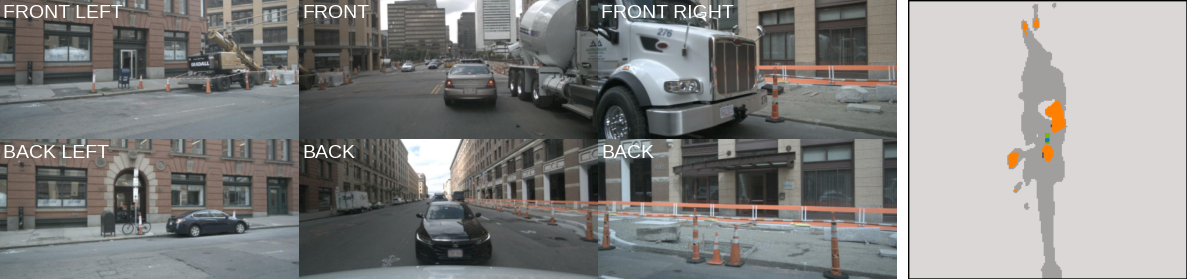

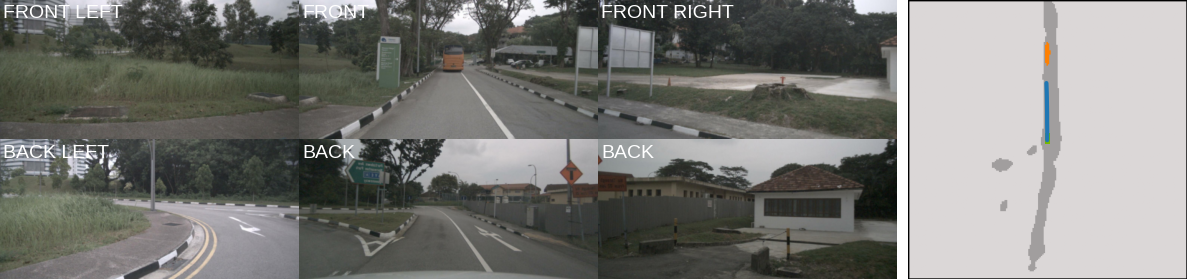

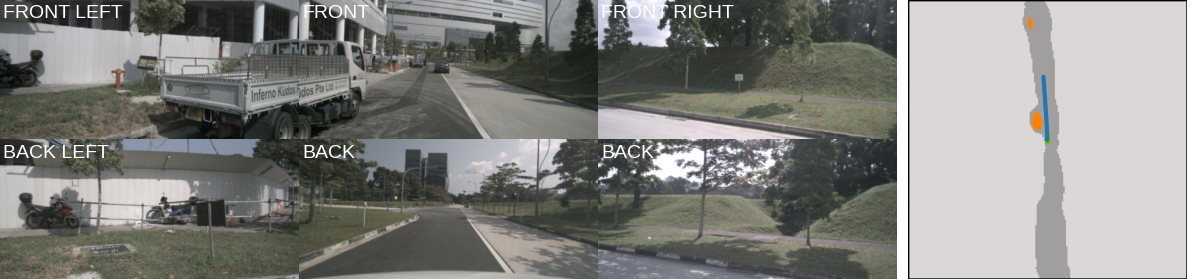

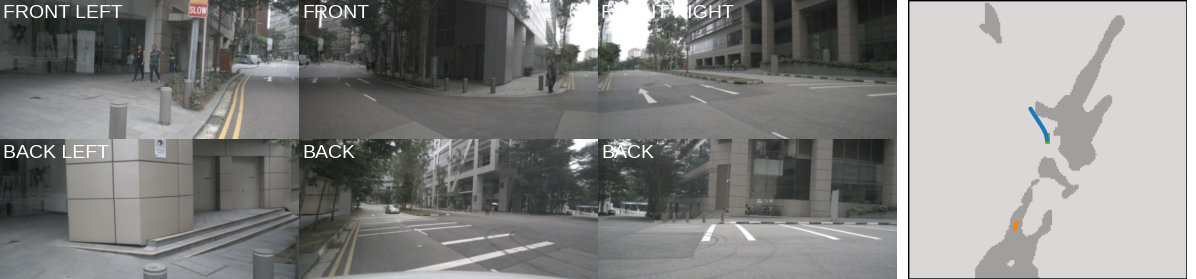

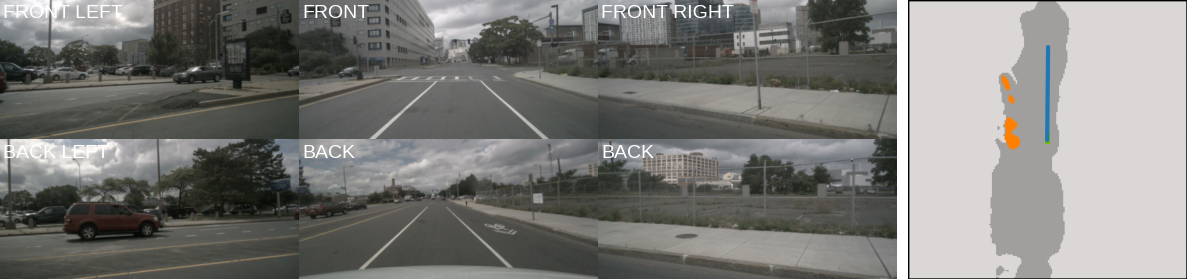

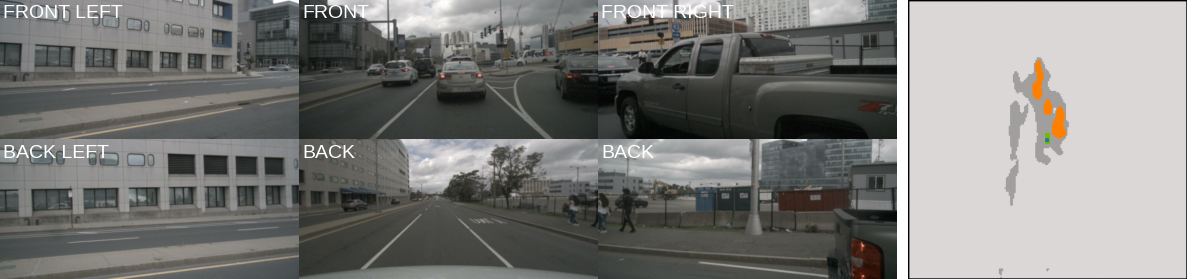

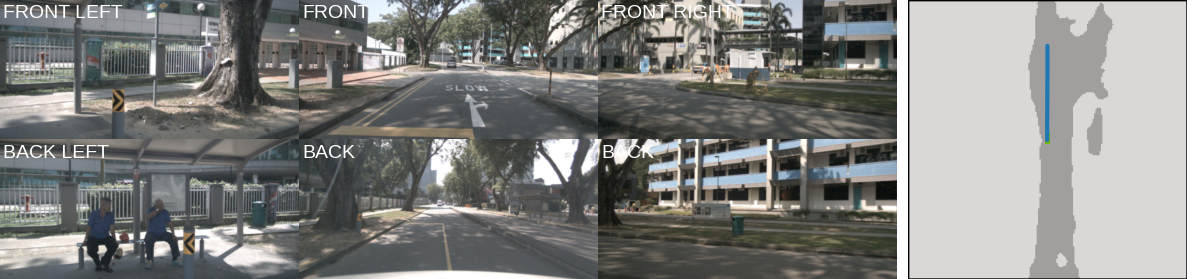

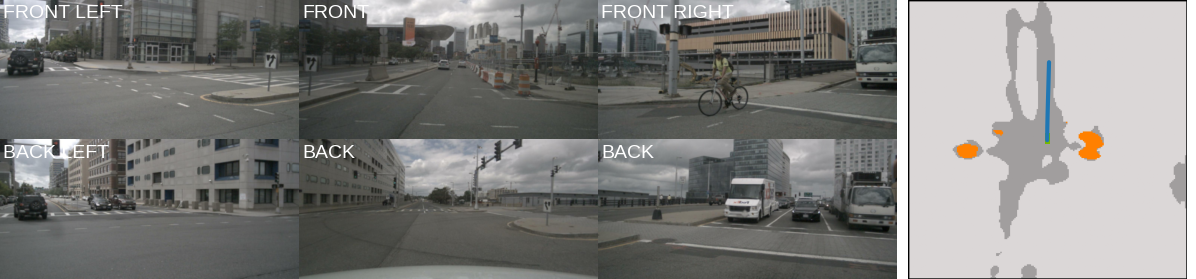

In [57]:
from IPython.display import Image, display
import os

image_folder = newest_dir

for filename in os.listdir(image_folder):
    if filename.endswith(('.jpg', '.jpeg', '.png', '.gif')):  # Adjust file extensions as needed
        image_path = os.path.join(image_folder, filename)
        display(Image(filename=image_path))

# upload logs

In [14]:
# from huggingface_hub import login
# from huggingface_hub import upload_folder

# token = secret_value
# login(token=token)

# # huggingface-cli login
# from huggingface_hub import create_repo

# repo_id = "marmoh2002/log-repository"
# create_repo(repo_id, repo_type="dataset", private=False, exist_ok=True)
# # Set private=True if you want your repository to be private
# local_folder_path = "/kaggle/working/tensorboard_logs/"
# path_in_repo = "logs/" # This will create a 'logs' folder in your HF repo

# upload_folder(
#     folder_path=local_folder_path,
#     repo_id=repo_id,
#     repo_type="dataset", # or "model"
#     path_in_repo=path_in_repo,
#     commit_message="Upload TensorBoard logs from Kaggle",
#     # ignore_patterns=["*.ckpt"] # Uncomment to ignore checkpoint files if not needed
# )

In [16]:
# !du -lah /kaggle/working/tensorboard_logs